In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))

from src.models import stacking_ensemble
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

c:\Users\Georgii\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
raw_path = os.path.dirname(os.path.abspath('.'))

save_probas = "..\probas"

df_FE_train_path = os.path.join(raw_path, "df_FE_train.csv")
df_FE_test_path = os.path.join(raw_path, "df_FE_test.csv")
df_FE = pd.read_csv(df_FE_train_path)
df_FE_test = pd.read_csv(df_FE_test_path)

X = df_FE.drop(['Stress_Level'], axis=1)
y = df_FE['Stress_Level']

y_test = df_FE_test['Stress_Level']

In [3]:
from imblearn.over_sampling import SMOTE
target_names = ['0', '1']
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X,y)

In [4]:
oof_rmlp_probas = np.load(os.path.join(save_probas, 'oof_RMLP_y_probas.npy'))
oof_tm_probas = np.load(os.path.join(save_probas, 'oof_TM_y_probas.npy'))
oof_etc_probas = np.load(os.path.join(save_probas, 'oof_ETC_y_probas.npy'))
oof_xgb_probas = np.load(os.path.join(save_probas, 'oof_XGB_y_probas.npy'))
oof_lgbm_probas = np.load(os.path.join(save_probas, 'oof_LGBM_y_probas.npy'))
oof_nn_probas = np.load(os.path.join(save_probas, 'oof_nn_probas.npy'))

rmlp_test_probas = np.load(os.path.join(save_probas, 'RMLP_test_probas.npy'))
tm_test_probas = np.load(os.path.join(save_probas, 'TM_test_probas.npy'))
etc_test_probas = np.load(os.path.join(save_probas, 'ETC_test_probas.npy'))
xgb_test_probas = np.load(os.path.join(save_probas, 'XGB_test_probas.npy'))
lgbm_test_probas = np.load(os.path.join(save_probas, 'LGBM_test_probas.npy'))
nn_test_probas = np.load(os.path.join(save_probas, 'nn_test_probas.npy'))

In [5]:
oof_probas_list = [oof_rmlp_probas, oof_tm_probas, oof_etc_probas, oof_xgb_probas, oof_lgbm_probas, oof_nn_probas]
test_probas_list = [rmlp_test_probas, tm_test_probas, etc_test_probas, xgb_test_probas, lgbm_test_probas, nn_test_probas]

for list in oof_probas_list:
    print(list.shape)

for list in test_probas_list:
    print(list.shape)

(18406, 2)
(18406, 2)
(18406, 2)
(18406, 2)
(18406, 2)
(18406, 2)
(4361, 2)
(4361, 2)
(4361, 2)
(4361, 2)
(4361, 2)
(4361, 2)


In [6]:
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(
    max_iter = 3000,
    C=0.01,
    random_state=42,
)

In [7]:
preds, probas, model = stacking_ensemble(oof_probas_list=oof_probas_list,
                                         y=y_resampled,
                                         test_probas_list=test_probas_list,
                                         meta_model=meta_model)



submission = pd.DataFrame({
    'class': preds,
})

submission.to_csv("..\preds\stacking_submission.csv", index=False)
print('Done')

Done


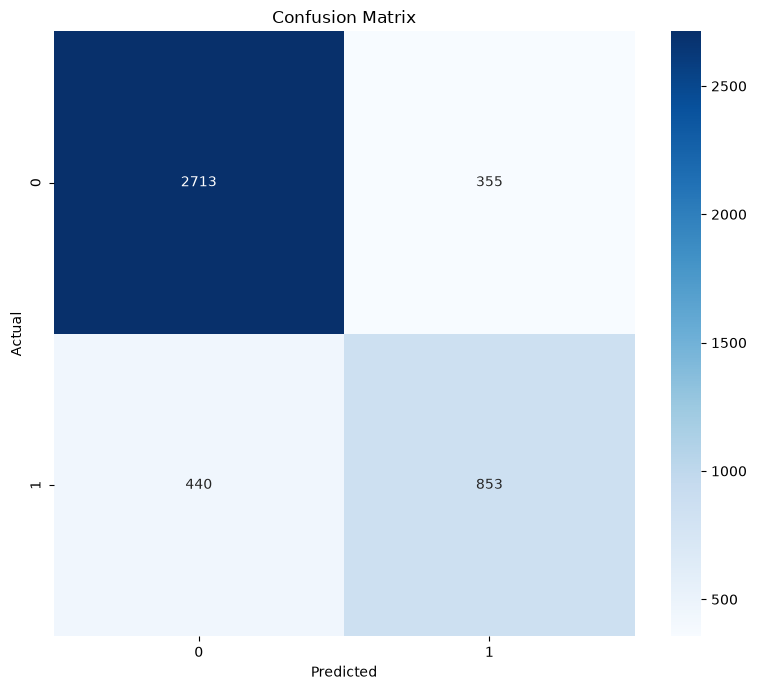

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      3068
           1       0.71      0.66      0.68      1293

    accuracy                           0.82      4361
   macro avg       0.78      0.77      0.78      4361
weighted avg       0.81      0.82      0.82      4361



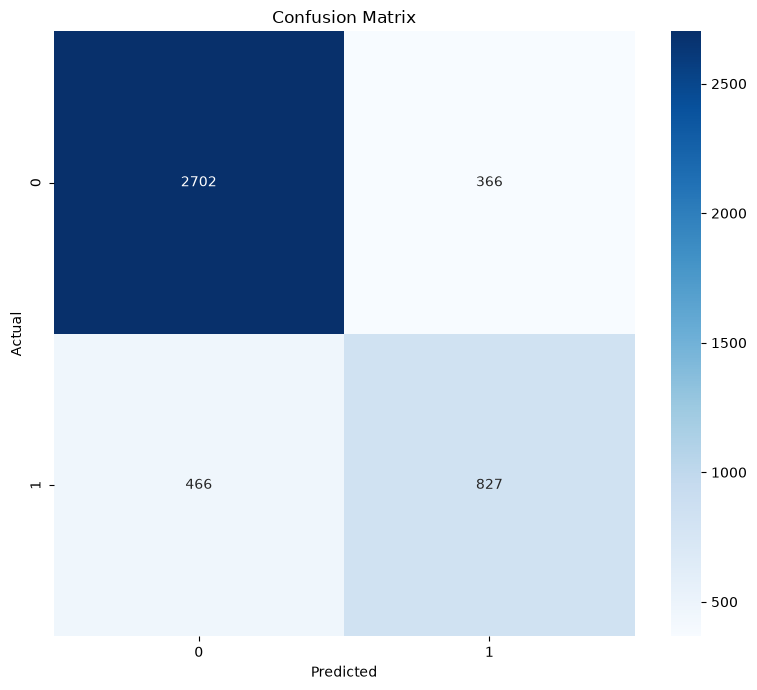

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      3068
           1       0.69      0.64      0.67      1293

    accuracy                           0.81      4361
   macro avg       0.77      0.76      0.77      4361
weighted avg       0.81      0.81      0.81      4361



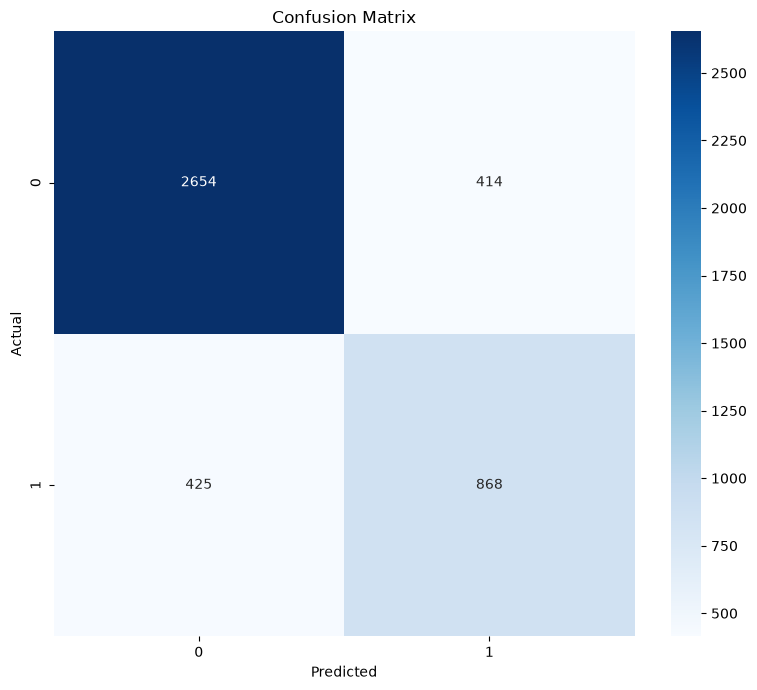

              precision    recall  f1-score   support

           0       0.86      0.87      0.86      3068
           1       0.68      0.67      0.67      1293

    accuracy                           0.81      4361
   macro avg       0.77      0.77      0.77      4361
weighted avg       0.81      0.81      0.81      4361



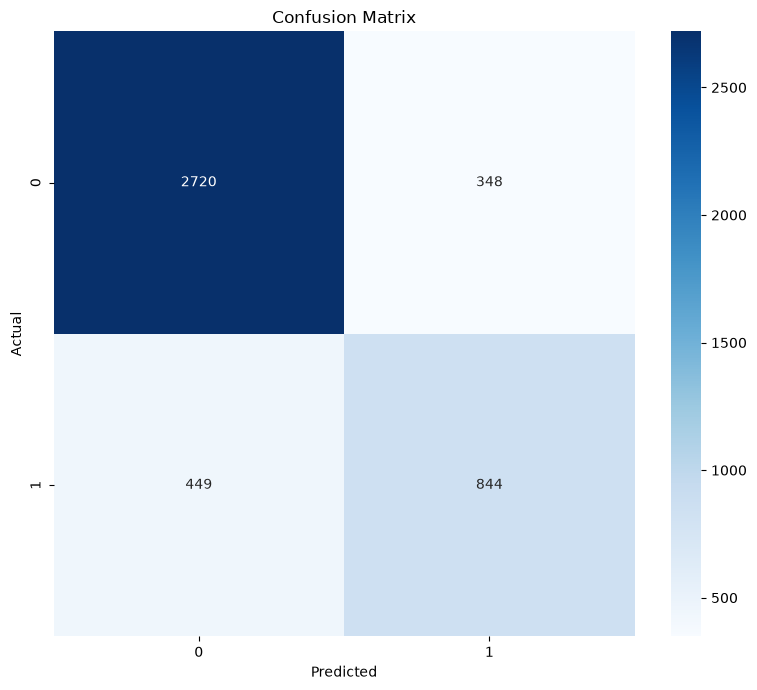

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      3068
           1       0.71      0.65      0.68      1293

    accuracy                           0.82      4361
   macro avg       0.78      0.77      0.78      4361
weighted avg       0.81      0.82      0.82      4361



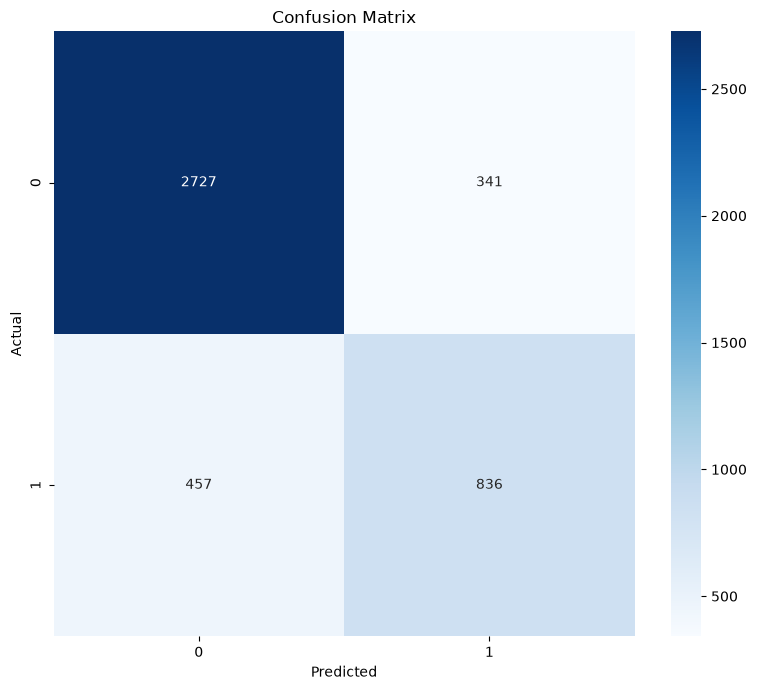

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      3068
           1       0.71      0.65      0.68      1293

    accuracy                           0.82      4361
   macro avg       0.78      0.77      0.77      4361
weighted avg       0.81      0.82      0.81      4361



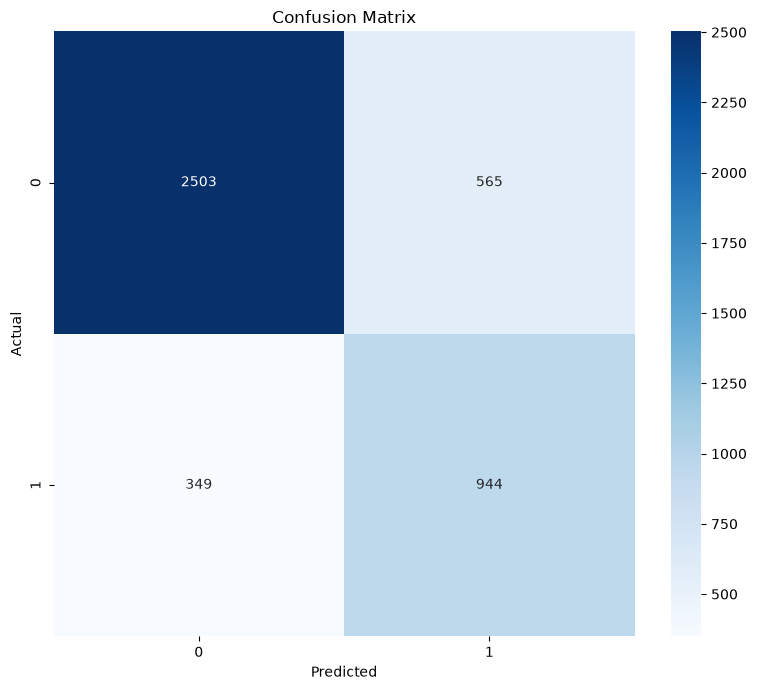

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      3068
           1       0.63      0.73      0.67      1293

    accuracy                           0.79      4361
   macro avg       0.75      0.77      0.76      4361
weighted avg       0.80      0.79      0.79      4361

Final evaluation


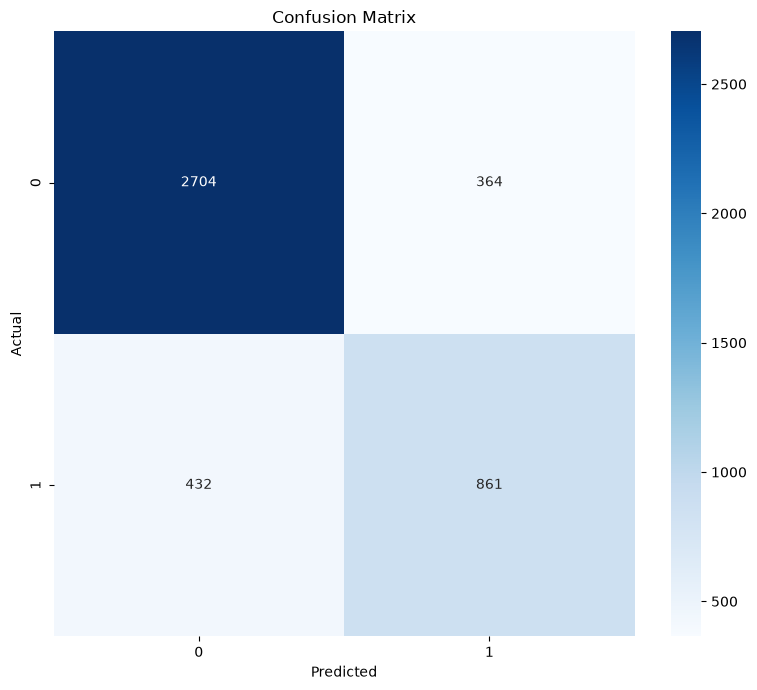

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      3068
           1       0.70      0.67      0.68      1293

    accuracy                           0.82      4361
   macro avg       0.78      0.77      0.78      4361
weighted avg       0.81      0.82      0.82      4361



In [8]:
from src.utils import show_confusion_matrix
from sklearn.metrics import classification_report

for probas in test_probas_list:
    past_preds = probas.argmax(axis=1)

    show_confusion_matrix(y_test, past_preds, target_names)
    print(classification_report(y_test, past_preds))
    print(f"{'='*60}")


print(f"Final evaluation")
show_confusion_matrix(y_test, preds, target_names)
print(classification_report(y_test, preds))